In [16]:
import torch
from torchvision import datasets, transforms




def get_mnist(batch_size, train):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.MNIST("data", 
                            train= train,
                            download=True,
                            transform = transform)
    dataset_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    return dataset_loader


In [17]:
train_dataset = get_mnist(batch_size=64, train=True)

In [18]:
import torch.nn as nn
# in order to support the convolutional layers, we need to compute 
# the output shape after the conv layers to properly define the linear
# layer in the encoder and the unflatten layer in the decoder. 
# We can do this by passing a dummy input through the conv layers 
# and checking the output shape.
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(1, latent_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(latent_dim, latent_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            conv_out = self.conv_encoder(dummy)
            self.conv_out_shape = conv_out.shape[1:]        # (C, H, W)
            flat_size = conv_out.flatten(1).shape[1]

        self.encoder = nn.Sequential(
            self.conv_encoder,
            nn.Flatten(),
            nn.Linear(flat_size, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, flat_size),
            nn.ReLU(),
            nn.Unflatten(1, self.conv_out_shape),
            nn.ConvTranspose2d(latent_dim, latent_dim, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(latent_dim, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [19]:
model_4 = ConvAutoencoder(latent_dim=4)
model_16 = ConvAutoencoder(latent_dim=16)


In [20]:
def train(model, train_loader, num_epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}]  L1 Loss: {total_loss / len(train_loader):.4f}")

    return model

model_4 = train(model_4, train_dataset, num_epochs=10, lr=1e-3)
model_16 = train(model_16, train_dataset, num_epochs=10, lr=1e-3)


Epoch [1/10]  L1 Loss: 0.1511
Epoch [2/10]  L1 Loss: 0.1248
Epoch [3/10]  L1 Loss: 0.1217
Epoch [4/10]  L1 Loss: 0.1197
Epoch [5/10]  L1 Loss: 0.1182
Epoch [6/10]  L1 Loss: 0.1171
Epoch [7/10]  L1 Loss: 0.1161
Epoch [8/10]  L1 Loss: 0.1155
Epoch [9/10]  L1 Loss: 0.1151
Epoch [10/10]  L1 Loss: 0.1147
Epoch [1/10]  L1 Loss: 0.1226
Epoch [2/10]  L1 Loss: 0.0846
Epoch [3/10]  L1 Loss: 0.0508
Epoch [4/10]  L1 Loss: 0.0439
Epoch [5/10]  L1 Loss: 0.0408
Epoch [6/10]  L1 Loss: 0.0391
Epoch [7/10]  L1 Loss: 0.0379
Epoch [8/10]  L1 Loss: 0.0370
Epoch [9/10]  L1 Loss: 0.0363
Epoch [10/10]  L1 Loss: 0.0358


In [ ]:
def evaluate(model, loader):
    device = next(model.parameters()).device
    model.eval()
    total_l1, n_batches = 0.0, 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructed = model(images)
            total_l1 += nn.functional.l1_loss(reconstructed, images).item()
            n_batches += 1
    avg_l1 = total_l1 / n_batches
    print(f"Test  L1 Loss: {avg_l1:.4f}")
    return avg_l1

test_dataset = get_mnist(batch_size=64, train=False)
evaluate(model_4, test_dataset)
evaluate(model_16, test_dataset)


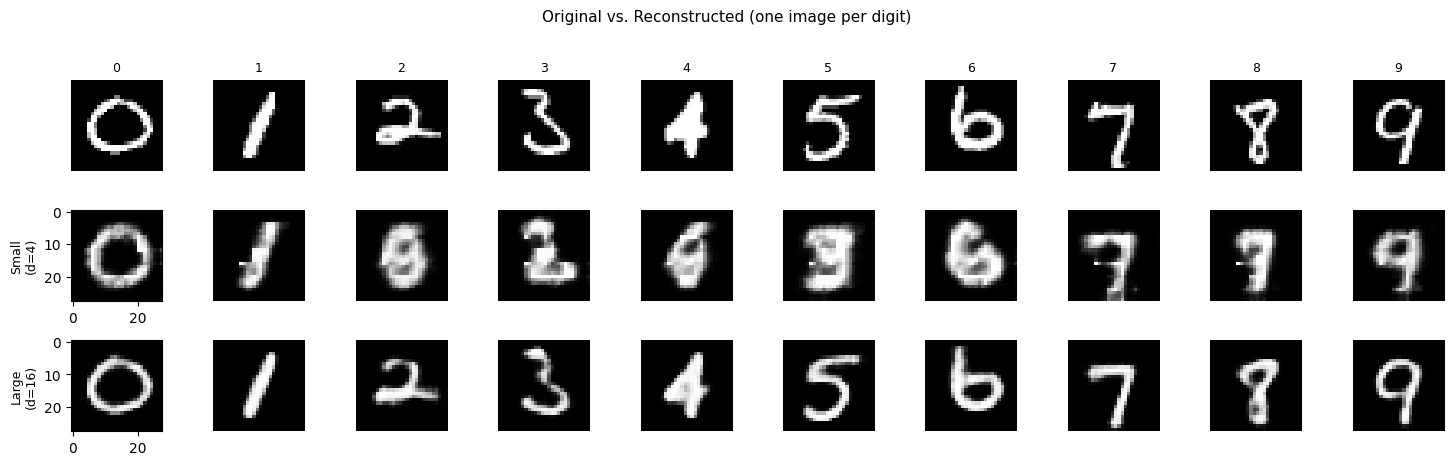

In [15]:
import matplotlib.pyplot as plt

def get_one_per_digit(loader):
    found = {}
    for images, labels in loader:
        for img, label in zip(images, labels):
            d = label.item()
            if d not in found:
                found[d] = img
            if len(found) == 10:
                break
        if len(found) == 10:
            break
    return torch.stack([found[d] for d in range(10)])  # ordered 0-9

def show_reconstructions(models_dict, images):
    n = images.shape[0]
    rows = 1 + len(models_dict)
    fig, axes = plt.subplots(rows, n, figsize=(n * 1.5, rows * 1.5))
    fig.suptitle("Original vs. Reconstructed (one image per digit)", fontsize=11, y=1.02)

    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(str(i), fontsize=9)
    axes[0, 0].set_ylabel("Original", fontsize=9)

    for row, (label, model) in enumerate(models_dict.items(), start=1):
        latent_dim = model.encoder[-1].out_features
        device = next(model.parameters()).device
        model.eval()
        with torch.no_grad():
            reconstructed = model(images.to(device)).cpu()
        for i in range(n):
            axes[row, i].imshow(reconstructed[i].squeeze(), cmap="gray")
            axes[row, i].axis("off")
        axes[row, 0].set_ylabel(f"{label}\n(d={latent_dim})", fontsize=9)
        axes[row, 0].axis("on")

    plt.tight_layout()
    plt.show()

test_loader = get_mnist(batch_size=256, train=False)
sample_images = get_one_per_digit(test_loader)

show_reconstructions({"Small": model_4, "Large": model_16}, sample_images)
